<div style="display: flex; align-items: center; gap: 16px;">
  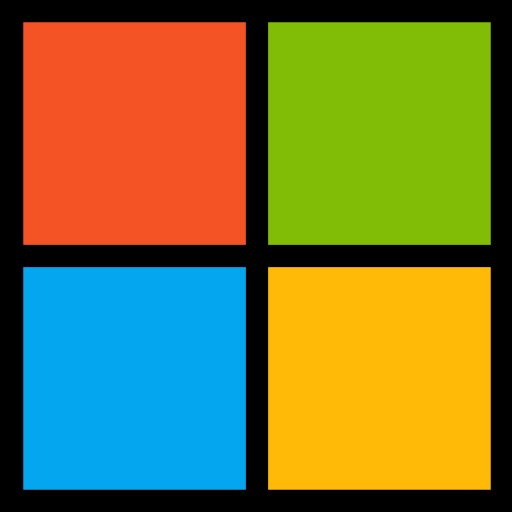
  <h1 style="color: #4A2D6F; font-weight: 800; margin: 0; flex: 1; text-align: center;">Microsoft Foundry: Agentic Observability — PoC</h1>
</div>
<p align="center" style="color: #666; font-style: italic; margin-top: -4px;">End-to-end proof of concept — from agent creation to trace validation in Log Analytics</p>

Build and interact with an AI Agent using Microsoft Foundry and the **Azure AI Projects SDK**.
The agent is configured for two tasks:

1. **Storytelling** — generate engaging stories from user prompts.
2. **Microsoft Learn via MCP** — query Foundry documentation through the Learn MCP endpoint.

For observability, the notebook wires up **Azure Monitor / OpenTelemetry tracing** to send agentic telemetry to:

- Microsoft Foundry — Tracing (Preview)
- Application Insights
- Interrogate Log Analytics (AppDependencies)

---

<h2 style="color: #D83B01;">Prerequisites</h2>

<details>
<summary><strong>Expand Prerequisites</strong></summary>

Before running this notebook, ensure the following are in place:

**1. Azure CLI Installed**

The notebook uses `DefaultAzureCredential`, which relies on Azure CLI for local authentication.

- **Install via winget (Windows):**
  ```powershell
  winget install --id Microsoft.AzureCLI -e --accept-source-agreements --accept-package-agreements
  ```
- **Other platforms / manual install:** [https://aka.ms/installazurecli](https://aka.ms/installazurecli)

**2. Logged in via Azure CLI with Appropriate Permissions**

After installing, sign in and verify your session:
```bash
az login
az account show
```
Your Entra ID identity must have **Contributor** (or equivalent) access to the Microsoft Foundry project and the associated Application Insights resource.

**3. Microsoft Foundry Project with Application Insights**

You need a project provisioned in **Microsoft Foundry** that is connected to an **Application Insights** instance backed by a **Log Analytics workspace**. The notebook retrieves the Application Insights connection string from the project at runtime to enable telemetry export.

</details>

---


<h2 style="color: #0078D4;">0. Create or Reuse Virtual Environment &amp; Register Kernel</h2>

<ul>
  <li>Create (or reuse) a Python virtual environment to isolate dependencies for this project, then install <code>ipykernel</code> and register it as a notebook kernel.</li>
  <li>Once setup is complete, select <strong>Kernel</strong> and choose your new <code>.venv</code> environment.</li>
</ul>


In [ ]:
import os
import subprocess
import sys

venv_dir = os.path.join(os.getcwd(), ".venv")

# Create the virtual environment (safe to run repeatedly)
subprocess.check_call([sys.executable, "-m", "venv", venv_dir])

# Resolve the venv Python path per OS, then use "python -m pip" for reliability
venv_python = (
    os.path.join(venv_dir, "Scripts", "python.exe")
    if os.name == "nt"
    else os.path.join(venv_dir, "bin", "python")
)

# Install / upgrade ipykernel inside the venv
subprocess.check_call([venv_python, "-m", "pip", "install", "--upgrade", "ipykernel"])

# Register the venv as a Jupyter kernel
subprocess.check_call([
    venv_python,
    "-m",
    "ipykernel",
    "install",
    "--user",
    "--name",
    "ai-agent-demo",
    "--display-name",
    "AI Agent Demo (.venv)",
])

print(f"Virtual environment created or reused at {venv_dir}")
print("Select the 'AI Agent Demo (.venv)' kernel in the top-right kernel picker, then continue.")

<h3 style="color: #D83B01;">Activate or Deactivate the Python Virtual Environment</h3>

Run the cell below to **activate** the <code style="color: #2EA043;">.venv</code> so it is recognized as an available kernel.

You only need to create the environment once (Section 0), but you may need to re-activate it after restarting VS Code or opening a new terminal session.

To **deactivate**, run <code style="color: #D29922;">deactivate</code> in your PowerShell terminal.


In [ ]:
import os
import subprocess
import sys

venv_dir = os.path.join(os.getcwd(), ".venv")
venv_dir_norm = os.path.normcase(os.path.normpath(venv_dir))

active_venv = os.environ.get("VIRTUAL_ENV", "")
active_venv_norm = os.path.normcase(os.path.normpath(active_venv)) if active_venv else ""

already_active = (
    active_venv_norm == venv_dir_norm
    or os.path.normcase(os.path.normpath(sys.prefix)) == venv_dir_norm
)

if already_active:
    print(f"ℹ️ .venv is already active: {venv_dir}")
else:
    # Resolve the activation script path per OS
    if os.name == "nt":
        activate_script = os.path.join(venv_dir, "Scripts", "Activate.ps1")
        subprocess.check_call(["powershell", "-ExecutionPolicy", "Bypass", "-File", activate_script])
    else:
        activate_script = os.path.join(venv_dir, "bin", "activate")
        subprocess.check_call(["bash", "-c", f"source {activate_script}"])

    print(f"✅ Virtual environment activated: {activate_script}")

print("You can now select the 'AI Agent Demo (.venv)' kernel in the top-right kernel picker.")

<h2 style="color: #0078D4;">1. Install Python Packages &amp; Dependencies</h2>

Install the required Python packages.

<details>
<summary><strong>Package Overview (Expand to view dependencies)</strong></summary>
<br>

📦 <code style="color: #0078D4; font-weight: 600;">azure-ai-projects</code>
 — SDK for working with Microsoft Foundry projects and agents.<br>
🔐 <code style="color: #0078D4; font-weight: 600;">azure-identity</code>
 — Provides <code>DefaultAzureCredential</code> for seamless Azure authentication via Entra ID.<br>
📡 <code style="color: #0E7C6B; font-weight: 600;">opentelemetry-sdk</code>
 — Core OpenTelemetry SDK for instrumentation and tracing.<br>
📊 <code style="color: #0078D4; font-weight: 600;">azure-monitor-opentelemetry</code>
 — All-in-one Azure Monitor OpenTelemetry distro (exporters, tracer providers, etc.).<br>
&emsp;↳ <code style="color: #888; font-weight: 500;">azure-core-tracing-opentelemetry</code>
 <span style="color: #666; font-size: 0.9em;">Transitive dep — Azure SDK tracing plugin.</span>

</details>


In [ ]:
import json
import subprocess
import sys

outdated = subprocess.check_output(
    [sys.executable, "-m", "pip", "list", "--outdated", "--format=json"],
    text=True,
)
if any(pkg["name"].lower() == "pip" for pkg in json.loads(outdated)):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])

# The "pre" flag allows installing beta versions, which is important for staying up to date with the latest GenAI tracing features.
%pip --disable-pip-version-check install --upgrade --pre azure-monitor-opentelemetry-exporter
%pip --disable-pip-version-check install --pre "azure-ai-projects>=2.0.0b4"
%pip --disable-pip-version-check install azure-identity azure-monitor-opentelemetry azure-core-tracing-opentelemetry

<h3 style="color: #D83B01;">Confirm Existing Azure / Microsoft Foundry Deployment</h3>

Load the latest <code style="color: #2EA043;">build_info-&lt;suffix&gt;.json</code> and print the current infrastructure summary before importing the Azure/Foundry libraries.

<table style="margin-top: 8px; border: none; border-collapse: collapse;">
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">📂</td>
    <td style="border: none; padding: 4px 0; color: #555;">Reads deployment metadata (resource group, Key Vault, App Insights, model, endpoints)</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">✅</td>
    <td style="border: none; padding: 4px 0; color: #555;">Confirms all resources are provisioned before proceeding</td>
  </tr>
</table>


In [ ]:
import json
from pathlib import Path

def resolve_build_info_path() -> Path:
    candidates = sorted(
        Path(".").glob("build_info-*.json"),
        key=lambda candidate: candidate.stat().st_mtime,
        reverse=True,
    )
    if candidates:
        return candidates[0]

    raise FileNotFoundError(
        r"No build_info-<suffix>.json file found. Run deployment/deploy-foundry-env.ps1 first to generate one."
    )

build_info_path = resolve_build_info_path()
build_info = json.loads(build_info_path.read_text(encoding="utf-8"))
foundry_proj_ep = build_info["foundry_project_endpoint"]
genai_model = build_info["genai_model"]
signed_in_account = globals().get("signed_in_account")

def show_current_build_status(
    build_info: dict,
    *,
    signed_in_account: str | None = None,
    app_insights_connection_status: str = "This project only ✅",
    law_rbac_status: str = "Log Analytics Reader on DIBSecCom ✅",
) -> None:
    user_status = (
        f"{signed_in_account} added to zolab-ai-dev ✅"
        if signed_in_account
        else "Signed-in account not available"
    )
    rows = [
        ("☁️ Resource Group", f"✅ {build_info['rg']}"),
        ("🗄️ Storage", build_info["storage_account"]),
        ("🔐 Key Vault", build_info["key_vault"]),
        ("📊 App Insights", build_info["appinsights"]),
        ("🤖 AI Foundry", build_info["foundry_name"]),
        ("🏢 AI Project", build_info["foundry_project_name"]),
        ("🧠 Model", f"{build_info['genai_model']} (GlobalStandard)"),
        ("📝 Build Info", build_info_path.name),
        ("🔗 App Insights Connection", app_insights_connection_status),
        ("📡 LAW RBAC", law_rbac_status),
        ("👤 User", user_status),
        ("🔌 Foundry Project Endpoint", build_info["foundry_project_endpoint"]),
        ("🤖 Azure OpenAI Endpoint", build_info["azure_openai_endpoint"]),
    ]

    item_width = max(29, max(len(item) for item, _ in rows) + 2)
    status_width = max(78, max(len(status) for _, status in rows) + 2)

    print()
    print("● ☁️🎉🚀 Your infrastructure is all green!")
    print()
    print("┌" + ("─" * item_width) + "┬" + ("─" * status_width) + "┐")
    print("│" + " Item".ljust(item_width) + "│" + " Status".ljust(status_width) + "│")
    print("├" + ("─" * item_width) + "┼" + ("─" * status_width) + "┤")
    for item, status in rows:
        print("│" + f" {item}".ljust(item_width) + "│" + f" {status}".ljust(status_width) + "│")
    print("└" + ("─" * item_width) + "┴" + ("─" * status_width) + "┘")
    print()
    print("Ready for the notebook! 🎯")

show_current_build_status(build_info, signed_in_account=signed_in_account)


<h2 style="color: #0078D4;">2. Import Libraries</h2>

Import the necessary classes from the Azure, Foundry, and OpenTelemetry SDKs.

<details>
<summary><strong>What Each Import Does</strong></summary>
<br>

🔐 <code style="color: #0078D4; font-weight: 600;">DefaultAzureCredential</code>
 <span style="color: #888; font-size: 0.88em;">azure-identity</span>
 — Picks up credentials from your environment (Azure CLI, managed identity, etc.).<br>
🤖 <code style="color: #0078D4; font-weight: 600;">AIProjectClient</code>
 <span style="color: #888; font-size: 0.88em;">azure-ai-projects</span>
 — Client for your Foundry project (setup, agent creation, telemetry connection string).<br>
✨ <code style="color: #0078D4; font-weight: 600;">PromptAgentDefinition</code>
 <span style="color: #888; font-size: 0.88em;">azure-ai-projects</span>
 — Defines the agent's model and behavior instructions.<br>
📡 <code style="color: #0E7C6B; font-weight: 600;">AIProjectInstrumentor</code>
 <span style="color: #888; font-size: 0.88em;">azure-ai-projects</span>
 — Instruments SDK and OpenAI operations for tracing (Section 3.1).<br>
📊 <code style="color: #0E7C6B; font-weight: 600;">configure_azure_monitor</code>
 <span style="color: #888; font-size: 0.88em;">azure-monitor-opentelemetry</span>
 — One-liner to set up Azure Monitor as the OpenTelemetry export backend.

</details>

<details>
<summary><strong>How the Pieces Wire Together</strong></summary>
<br>

The notebook connects the Foundry SDK to the telemetry stack in four steps:<br>

<span style="color: #0078D4; font-weight: 700;">①</span>
 <code style="color: #0078D4;">project_client.telemetry.get_application_insights_connection_string()</code>
 — retrieves the destination from the Foundry project.<br>
<span style="color: #0078D4; font-weight: 700;">②</span>
 <code style="color: #0078D4;">configure_azure_monitor(...)</code>
 — initializes the Azure Monitor OpenTelemetry pipeline.<br>
<span style="color: #0078D4; font-weight: 700;">③</span>
 <code style="color: #0E7C6B;">AIProjectInstrumentor().instrument(...)</code>
 — instruments <code>azure-ai-projects</code> and OpenAI operations.<br>
<span style="color: #0078D4; font-weight: 700;">④</span>
 Manual spans (<code style="color: #D83B01;">create_agent</code>, <code style="color: #D83B01;">invoke_agent</code>)
 — add business context for troubleshooting.<br>

<table style="border: none; border-collapse: collapse; margin-top: 4px;">
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">🏗️</td>
    <td style="border: none; padding: 4px 0; color: #555;"><strong>Foundry SDK</strong> — project setup, agent creation/query, connection string retrieval.</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">📡</td>
    <td style="border: none; padding: 4px 0; color: #555;"><strong>Telemetry Stack</strong> — <code>opentelemetry-sdk</code> (tracing runtime) → <code>azure-core-tracing-opentelemetry</code> (bridge) → <code>azure-monitor-opentelemetry</code> (exporter).</td>
  </tr>
</table>

</details>

<details>
<summary><strong>MSFT Learn References</strong></summary>

- [Microsoft Foundry tracing flow](https://learn.microsoft.com/azure/foundry-classic/how-to/develop/trace-agents-sdk#instrument-tracing-in-your-code)
- [Azure Monitor ()](https://learn.microsoft.com/python/api/overview/azure/monitor-opentelemetry-readme?view=azure-python#getting-started)
- [Azure Core tracing bridge](https://learn.microsoft.com/python/api/overview/azure/core-tracing-opentelemetry-readme?view=azure-python-preview#getting-started)

</details>


In [ ]:
import sys, platform

from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient
from azure.ai.projects.models import PromptAgentDefinition
from azure.ai.projects.telemetry import AIProjectInstrumentor

print("✅ All libraries imported successfully")
print(f"   💻 Platform: {platform.system()} {platform.release()}")
print(f"   🐍 Python:   {sys.version.split()[0]}")

<h2 style="color: #0078D4;">3. Configure the Project Client</h2>

- Reuse the deployment values loaded in the **Confirm Existing Deployment** section above.
- Create an authenticated `AIProjectClient` instance.
- Confirm which credential was selected for this notebook session.


In [ ]:
import json
import logging
import os
import shutil
import subprocess
from pathlib import Path

# build_info and build_info_path are set in Section 0
foundry_proj_ep = build_info["foundry_project_endpoint"]
genai_model = build_info["genai_model"]
signed_in_account = globals().get("signed_in_account")

# ---------------------------------------------------------------------------
def _install_az_cli() -> bool:
    """Attempt to install Azure CLI using winget. Returns True on success."""
    if os.name != "nt":
        print("❌ Automatic install via winget is only supported on Windows.")
        print("   👉 Install Azure CLI from: https://aka.ms/installazurecli")
        return False

    if not shutil.which("winget"):
        print("❌ winget is not available on this system.")
        print("   👉 Install Azure CLI manually from: https://aka.ms/installazurecli")
        return False

    print("📦 Installing Azure CLI via winget … (this may take a few minutes)")
    result = subprocess.run(
        ["winget", "install", "--id", "Microsoft.AzureCLI", "-e", "--accept-source-agreements", "--accept-package-agreements"],
        capture_output=True, text=True, timeout=300,
    )
    if result.returncode == 0:
        print("✅ Azure CLI installed successfully.")
        az_default = os.path.join(os.environ.get("ProgramFiles", r"C:\Program Files"), "Microsoft SDKs", "Azure", "CLI2", "wbin")
        if os.path.isdir(az_default) and az_default not in os.environ.get("PATH", ""):
            os.environ["PATH"] = az_default + os.pathsep + os.environ["PATH"]
            print(f"   Added {az_default} to PATH for this session.")
        return True
    else:
        print(f"❌ winget install failed (exit code {result.returncode}).")
        if result.stderr:
            print(f"   {result.stderr.strip()}")
        print("   👉 Try installing manually from: https://aka.ms/installazurecli")
        return False


# ---------------------------------------------------------------------------
# Helper: check for Azure CLI and attempt interactive login if needed
# ---------------------------------------------------------------------------
def _ensure_az_login() -> bool:
    """Return True if Azure CLI is available and the user is logged in."""
    az_exe = "az.cmd" if os.name == "nt" else "az"

    if not shutil.which(az_exe):
        print("⚠️  Azure CLI is NOT installed.")
        if not _install_az_cli():
            return False
        if not shutil.which(az_exe):
            print("❌ Azure CLI still not found on PATH after install.")
            print("   Please restart VS Code so the updated PATH takes effect, then re-run this cell.")
            return False

    print("🔍 Azure CLI found on PATH — checking login status …")

    check = subprocess.run(
        [az_exe, "account", "show"],
        capture_output=True, text=True, timeout=15,
    )
    if check.returncode == 0:
        print("✅ Already logged in to Azure CLI.")
        return True

    print("⚠️  No active Azure CLI session detected. Launching 'az login' …")
    print("   A browser window should open — please sign in with your Azure account.\n")
    login = subprocess.run([az_exe, "login"], capture_output=True, text=True, timeout=120)
    if login.returncode == 0:
        if login.stdout:
            print(login.stdout.strip())
        print("\n✅ Azure CLI login succeeded.")
        return True
    else:
        print(f"\n❌ 'az login' did not complete successfully (exit code {login.returncode}).")
        if login.stderr:
            print(f"   {login.stderr.strip()}")
        print("   Please run 'az login' manually in a terminal, then re-run this cell.")
        return False


# ---------------------------------------------------------------------------
# Authenticate
# ---------------------------------------------------------------------------
credential = DefaultAzureCredential()

_identity_handler = logging.StreamHandler()
identity_logger = logging.getLogger("azure.identity")
identity_logger.addHandler(_identity_handler)
identity_logger.setLevel(logging.INFO)

signed_in_account = None

try:
    _ = credential.get_token("https://management.azure.com/.default")

except Exception as auth_ex:
    print(f"⚠️  DefaultAzureCredential failed: {type(auth_ex).__name__}")
    print("   Falling back to Azure CLI authentication …\n")

    if not _ensure_az_login():
        raise SystemExit(
            "🛑 Cannot proceed without valid Azure credentials. "
            "Please install/login to Azure CLI and re-run this cell."
        )

    credential = DefaultAzureCredential()
    _ = credential.get_token("https://management.azure.com/.default")

finally:
    identity_logger.removeHandler(_identity_handler)
    identity_logger.setLevel(logging.WARNING)

project_client = AIProjectClient(
    endpoint=foundry_proj_ep,
    credential=credential,
)

_lw = 14
print("\n✅ AIProjectClient Configured")
print(f"   🌐 {'Endpoint:':<{_lw}} {foundry_proj_ep}")
print(f"   🧠 {'Model:':<{_lw}} {genai_model}")
print(f"   📄 {'Build info:':<{_lw}} {build_info_path.resolve()}")
print(f"   🔐 {'Auth:':<{_lw}} DefaultAzureCredential")


# ---------------------------------------------------------------------------
# Optional: surface which credential + identity is in use
# ---------------------------------------------------------------------------
def _run_command(command: list[str]) -> str | None:
    try:
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=10,
            check=False,
        )
        if result.returncode == 0:
            value = (result.stdout or "").strip()
            return value or None
    except Exception:
        pass
    return None


def _resolve_identity_hint(credential_name: str) -> str | None:
    if credential_name == "AzureCliCredential":
        az_exe = "az.cmd" if os.name == "nt" else "az"
        return _run_command([az_exe, "account", "show", "--query", "user.name", "-o", "tsv"])
    if credential_name == "AzurePowerShellCredential":
        powershell_cmd = "$ctx = Get-AzContext; if ($ctx -and $ctx.Account) { $ctx.Account.Id }"
        return _run_command(["pwsh", "-NoProfile", "-Command", powershell_cmd])
    return None


try:
    selected_credential = getattr(credential, "_successful_credential", None)
    if selected_credential is not None:
        credential_name = selected_credential.__class__.__name__
        credential_name_color = globals().get("ansi_magenta", "\033[95m")
        credential_ansi_reset = globals().get("ansi_reset", "\033[0m")
        credential_name_colored = f"{credential_name_color}{credential_name}{credential_ansi_reset}"
        print(f"      🔐 Credential used: {credential_name_colored}")

        identity_hint = _resolve_identity_hint(credential_name)
        if identity_hint:
            signed_in_account = identity_hint
            print(f"      👤 Signed-in account: {identity_hint}")
        else:
            print("      👤 Signed-in account: not available for this credential type")
    else:
        print("      Credential Type: check azure.identity INFO logs above")
except Exception as ex:
    print(f"      Credential probe skipped: {type(ex).__name__}: {ex}")


<h2 style="color: #0078D4;">3.1 Enable AI Agent (client-side) Observability/Telemetry</h2>

<details>
<summary><strong>Tracing Setup Overview</strong></summary>

Configure tracing per the [Azure AI Projects SDK tracing guide](https://github.com/Azure/azure-sdk-for-python/tree/main/sdk/ai/azure-ai-projects#tracing):
1. **`configure_azure_monitor`** — Sets up the full OpenTelemetry pipeline (TracerProvider, exporter, span processors) to send traces to Application Insights
2. **`AIProjectInstrumentor`** — Instruments all `azure-ai-projects` SDK operations (agent create/version, list, etc.) and automatically instruments OpenAI responses/conversations operations

**Note:**
- `AZURE_EXPERIMENTAL_ENABLE_GENAI_TRACING=true` must be set **before** calling `instrument()`.
- `OTEL_SEMCONV_STABILITY_OPT_IN=gen_ai_latest_experimental` opts into the latest experimental GenAI semantic conventions.
- Content recording is controlled by `OTEL_INSTRUMENTATION_GENAI_CAPTURE_MESSAGE_CONTENT`.

</details>

In [ ]:
from uuid import uuid4

from azure.core.settings import settings
from opentelemetry import baggage, context as otel_context, trace
from opentelemetry.sdk.resources import Resource
from azure.monitor.opentelemetry import configure_azure_monitor

settings.tracing_implementation = "opentelemetry"

# ---------------------------------------------------------------------------
# Phase 1: Trace settings (must be set before instrumentation)
# ---------------------------------------------------------------------------
os.environ["AZURE_EXPERIMENTAL_ENABLE_GENAI_TRACING"] = "true"
os.environ["OTEL_SEMCONV_STABILITY_OPT_IN"] = "gen_ai_latest_experimental"
os.environ["OTEL_INSTRUMENTATION_GENAI_CAPTURE_MESSAGE_CONTENT"] = "true"
os.environ["AZURE_TRACING_GEN_AI_CONTENT_RECORDING_ENABLED"] = "true"
os.environ["AZURE_TRACING_GEN_AI_ENABLE_TRACE_CONTEXT_PROPAGATION"] = "true"
os.environ["AZURE_TRACING_GEN_AI_TRACE_CONTEXT_PROPAGATION_INCLUDE_BAGGAGE"] = "true"

project_name = foundry_proj_ep.rstrip("/").split("/")[-1] if "foundry_proj_ep" in globals() else "unknown-project"
os.environ["OTEL_SERVICE_NAME"] = f"foundry-ai-agent-1702"
os.environ["OTEL_TRACES_SAMPLER"] = "microsoft.fixed_percentage"
os.environ["OTEL_TRACES_SAMPLER_ARG"] = "1.0"

if "telemetry_session_id" not in globals():
    telemetry_session_id = str(uuid4())

# -----------------------------------------------------------------------------
# Phase 2: Backend setup (Microsoft Foundry -> Application Insights connection)
# -----------------------------------------------------------------------------
application_insights_connection_string = project_client.telemetry.get_application_insights_connection_string()

resource = Resource.create(
    {
        "service.name": os.environ["OTEL_SERVICE_NAME"],
        "service.namespace": "foundry-agent-1702",
        "service.instance.id": telemetry_session_id,
        "deployment.environment": "demo",
        "foundry.project.name": project_name,
    }
)

# Configure Azure Monitor as the tracing backend.
configure_azure_monitor(
    connection_string=application_insights_connection_string,
    resource=resource,
    sampling_ratio=1.0,
)

# -----------------------------------------------------------------------------
# Phase 3: SDK instrumentation
# -----------------------------------------------------------------------------
AIProjectInstrumentor().instrument(enable_content_recording=True)

# -----------------------------------------------------------------------------
# Phase 4: Tracer handle for custom spans in later sections
# -----------------------------------------------------------------------------
tracer = trace.get_tracer(__name__)


def make_baggage_context(values: dict[str, object]):
    context = otel_context.get_current()
    for key, value in values.items():
        if value is None:
            continue
        value_text = str(value).strip()
        if value_text:
            context = baggage.set_baggage(key, value_text, context=context)
    return context


ansi_cyan = ""
ansi_magenta = ""
ansi_reset = ""
project_name_color = ansi_magenta
project_name_colored = f"{project_name_color}{project_name}{ansi_reset}"
foundry_label_colored = f"{project_name_color}Microsoft Foundry{ansi_reset}"

print(f"Tracing enabled -> Application Insights for project: '{project_name_colored}'")
print(f"- [connection string retrieved from: {foundry_label_colored}]")
print(f"- OTEL service name: {project_name_color}{os.environ['OTEL_SERVICE_NAME']}{ansi_reset}")
print(f"- Telemetry session id: {telemetry_session_id}")
print("- Trace context propagation: enabled")
print("- Baggage propagation: enabled")
print("- Content recording: enabled")
print("- Trace sampling: 100%")


<h3 style="color: #0078D4;">3.2 Configure MSFT Learn MCP Tool</h3>

Run this step to create `mcp_tool_spec` for use in Step 4.

<details>
<summary><strong>MSFT Learn MCP Tool Setup</strong></summary>

- MSFT Learn MCP documentation: [Azure MCP Server docs](https://learn.microsoft.com/azure/developer/azure-mcp-server/)
- MSFT Learn MCP URL: [Microsoft Learn MCP Endpoint](https://learn.microsoft.com/api/mcp)
- It builds an `MCPTool` spec with server label `msft-learn`.
- Step 4 uses this object via `tools=[mcp_tool_spec]` when creating the agent.

</details>

In [ ]:
# ---------------------------------------------------------------------------
# MSFT Learn MCP Tool Spec (used by Step 4 agent creation)
# ---------------------------------------------------------------------------
from azure.ai.projects.models import MCPTool

msft_learn_mcp_url = "https://learn.microsoft.com/api/mcp"
print(f"MSFT Learn MCP URL: {msft_learn_mcp_url}")

mcp_tool_spec = MCPTool(
    server_label="msft-learn",
    server_url=msft_learn_mcp_url,
)

<h2 style="color: #0078D4;">4. Create the AI Agent</h2>

<table style="border: none; border-collapse: collapse; margin-top: 4px;">
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">✨</td>
    <td style="border: none; padding: 4px 0; color: #555;">Storytelling persona — crafts engaging 6-sentence stories from user prompts</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">🔧</td>
    <td style="border: none; padding: 4px 0; color: #555;">MSFT Learn MCP tool attached for Foundry documentation lookups</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">🔄</td>
    <td style="border: none; padding: 4px 0; color: #555;"><code style="color: #0078D4;">create_version</code> is idempotent — only bumps the version when parameters change</td>
  </tr>
</table>


In [ ]:
from uuid import uuid4
from opentelemetry.trace import SpanKind, Status, StatusCode

agent_name = "ZoDEfendersAgent-1702"
model_name = genai_model

agent_instructions = (
    "You are an illuminating cybernetic storytelling agent. "
    "You craft engaging 6-sentence stories based on user prompts and context. "
    "Be sure to use vivid language and creative scenarios to captivate the reader. "
    "Use the full names of any characters you create in the story. "
    "Lastly, you are also a helpful assistant for learning about Microsoft technologies. "
    "If asked, employ the tools available to answer questions and provide relevant topic information."
)

# Shared run correlation id across notebook steps (created once per kernel session)
if "demo_run_id" not in globals():
    demo_run_id = str(uuid4())

tool_labels = [getattr(mcp_tool_spec, "server_label", "unknown-tool")]
agent_creation_context = make_baggage_context(
    {
        "demo-run-id": demo_run_id,
        "agent-name": agent_name,
        "model-name": model_name,
        "project-name": globals().get("project_name", "unknown-project"),
        "telemetry-session-id": globals().get("telemetry_session_id", ""),
    }
)

# OTel GenAI Agent semconv-compliant create span
with tracer.start_as_current_span(
    f"create_agent {agent_name}",
    kind=SpanKind.CLIENT,
    context=agent_creation_context,
) as span:
    span.set_attribute("gen_ai.operation.name", "create_agent")
    span.set_attribute("gen_ai.provider.name", "azure.ai.openai")
    span.set_attribute("gen_ai.request.model", model_name)
    span.set_attribute("gen_ai.agent.name", agent_name)
    span.set_attribute("gen_ai.agent.description", agent_instructions)
    span.set_attribute("demo.run_id", demo_run_id)
    span.set_attribute("app.session.id", globals().get("telemetry_session_id", ""))
    span.set_attribute("agent.tools.count", len(tool_labels))
    span.set_attribute("agent.tools.labels", ",".join(tool_labels))
    span.add_event("create_agent.start")

    try:
        # Creates an agent, bumps the agent version if parameters have changed
        agent = project_client.agents.create_version(
            agent_name=agent_name,
            definition=PromptAgentDefinition(
                model=model_name,
                instructions=agent_instructions,
                tools=[mcp_tool_spec],
            ),
        )
        span.set_attribute("gen_ai.agent.id", agent.id)
        span.set_attribute("gen_ai.agent.version", str(agent.version))
        span.add_event("create_agent.success")
    except Exception as ex:
        span.record_exception(ex)
        span.set_attribute("error.type", type(ex).__name__)
        span.set_status(Status(StatusCode.ERROR, str(ex)))
        span.add_event("create_agent.failure")
        raise

agent_name_color = globals().get("ansi_magenta", "")
agent_ansi_reset = globals().get("ansi_reset", "")
agent_name_colored = f"{agent_name_color}{agent.name}{agent_ansi_reset}"

print(f"Agent created: {agent_name_colored} (id: {agent.id}, version: {agent.version})")
print(f"Run correlation id: {demo_run_id}")


<h2 style="color: #0078D4;">5. Query the Agent</h2>

<table style="border: none; border-collapse: collapse; margin-top: 4px;">
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">📖</td>
    <td style="border: none; padding: 4px 0; color: #555;"><strong>Pass 1</strong> — generate a fictional story from the agent's storytelling persona</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">🔍</td>
    <td style="border: none; padding: 4px 0; color: #555;"><strong>Pass 2</strong> — retrieve factual guidance from MSFT Learn via the MCP tool</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">💾</td>
    <td style="border: none; padding: 4px 0; color: #555;">Both results appended to <code style="color: #2EA043;">stories.json</code> with full metadata</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">📡</td>
    <td style="border: none; padding: 4px 0; color: #555;">Each interaction wrapped in an <code style="color: #0E7C6B;">OpenTelemetry</code> span for trace correlation</td>
  </tr>
</table>


In [ ]:
import json
from datetime import datetime, timezone
from pathlib import Path

from opentelemetry import context as otel_context
from opentelemetry.trace import SpanKind

story_prompt = (
    "Write about a Cloud Solutions Architect - Security by the name of 'Azure Zo' in Frankfurt, Germany. "
    "He is a man who moonlights as a cybernetic superhero called 'Die DEfender', protector of the digital realm. "
    "Include a plot twist in the last sentence. Always refer to the two characters by their full names."
)

facts_prompt = (
    "Use the MSFT Learn MCP tool to explain what Microsoft Foundry is for a Cloud Solutions Architect - Security. "
    "Return concise factual guidance only with this exact structure:\n"
    "MSFT Learn Insights:\n"
    "- 3 to 5 key points\n"
    "- Security and governance considerations\n"
    "- Practical next steps\n"
    "Sources:\n"
    "- Include at least one Microsoft Learn URL"
)

MAX_APPROVAL_ROUNDS = 5
agent_reference_payload = {
    "agent_reference": {
        "name": agent.name,
        "id": agent.id,
        "type": "agent_reference",
    }
}
conversation_ids: dict[str, str] = {}

with project_client.get_openai_client() as openai_client:
    def parse_response(response) -> tuple[str, list[str], list[str], object]:
        output_items = getattr(response, "output", None) or []
        output_types = [getattr(item, "type", type(item).__name__) for item in output_items]

        approval_ids = [
            item.id
            for item in output_items
            if getattr(item, "type", None) == "mcp_approval_request" and getattr(item, "id", None)
        ]

        text_parts = []
        for item in output_items:
            for content in getattr(item, "content", None) or []:
                text_obj = getattr(content, "text", None)
                if isinstance(text_obj, str) and text_obj.strip():
                    text_parts.append(text_obj)
                elif hasattr(text_obj, "value") and isinstance(text_obj.value, str) and text_obj.value.strip():
                    text_parts.append(text_obj.value)

        text = (getattr(response, "output_text", None) or "\n".join(text_parts)).strip()
        return text, approval_ids, output_types, getattr(response, "incomplete_details", None)

    def run_query_with_auto_approval(openai_client, agent_reference_payload, prompt, interaction_name, interaction_span, max_rounds=5):
        conversation = openai_client.conversations.create()
        print(f"Conversation created: {conversation.id}")
        interaction_span.add_event(
            "conversation.created",
            {
                "app.conversation.id": conversation.id,
                "app.interaction": interaction_name,
            },
        )

        baggage_values = {
            "demo-run-id": globals().get("demo_run_id", ""),
            "agent-name": agent.name,
            "agent-id": agent.id,
            "agent-version": getattr(agent, "version", ""),
            "interaction-name": interaction_name,
            "conversation-id": conversation.id,
            "model-name": model_name,
            "telemetry-session-id": globals().get("telemetry_session_id", ""),
        }

        def create_agent_response(response_input):
            baggage_token = otel_context.attach(make_baggage_context(baggage_values))
            try:
                return openai_client.responses.create(
                    conversation=conversation.id,
                    input=response_input,
                    extra_body=agent_reference_payload,
                )
            finally:
                otel_context.detach(baggage_token)

        response = create_agent_response(prompt)
        approvals_granted = 0

        for round_number in range(1, max_rounds + 1):
            text, approval_ids, output_types, incomplete_details = parse_response(response)
            status = getattr(response, "status", "unknown")

            print(f"Response status: {status}")
            print(f"Response output types: {output_types}")
            if incomplete_details:
                print(f"Incomplete details: {incomplete_details}")
                interaction_span.add_event(
                    "response.incomplete",
                    {"app.incomplete_details": str(incomplete_details)},
                )

            interaction_span.set_attribute("app.response.status", status)
            interaction_span.set_attribute("app.response.output_types", ",".join(output_types))

            if text or not approval_ids:
                interaction_span.add_event(
                    "response.completed",
                    {
                        "gen_ai.response.id": response.id,
                        "app.approval.rounds": approvals_granted,
                    },
                )
                return conversation.id, response, text, approvals_granted

            approvals_granted += len(approval_ids)
            interaction_span.add_event(
                "mcp.approval.auto_approved",
                {
                    "app.approval.round": round_number,
                    "app.approval.count": len(approval_ids),
                },
            )
            print(f"Approving MCP tool requests (round {round_number}): {approval_ids}")
            response = create_agent_response(
                [
                    {
                        "type": "mcp_approval_response",
                        "approve": True,
                        "approval_request_id": request_id,
                    }
                    for request_id in approval_ids
                ]
            )

        final_text, _, _, _ = parse_response(response)
        interaction_span.add_event(
            "response.max_approval_rounds_reached",
            {"app.approval.rounds": approvals_granted},
        )
        print("⚠️ Reached maximum MCP approval rounds without assistant text output.")
        return conversation.id, response, final_text, approvals_granted

    def run_interaction_with_span(*, interaction_name: str, prompt: str):
        interaction_context = make_baggage_context(
            {
                "demo-run-id": globals().get("demo_run_id", ""),
                "agent-name": agent.name,
                "agent-id": agent.id,
                "agent-version": getattr(agent, "version", ""),
                "interaction-name": interaction_name,
                "model-name": model_name,
                "project-name": globals().get("project_name", "unknown-project"),
                "telemetry-session-id": globals().get("telemetry_session_id", ""),
            }
        )
        with tracer.start_as_current_span(
            f"invoke_agent {agent.name}",
            kind=SpanKind.CLIENT,
            context=interaction_context,
        ) as interaction_span:
            if "demo_run_id" in globals():
                interaction_span.set_attribute("demo.run_id", demo_run_id)
            interaction_span.set_attribute("gen_ai.operation.name", "invoke_agent")
            interaction_span.set_attribute("gen_ai.provider.name", "azure.ai.openai")
            interaction_span.set_attribute("gen_ai.request.model", model_name)
            interaction_span.set_attribute("gen_ai.agent.name", agent.name)
            interaction_span.set_attribute("gen_ai.agent.id", agent.id)
            interaction_span.set_attribute("gen_ai.agent.version", str(getattr(agent, "version", "")))
            interaction_span.set_attribute("app.interaction", interaction_name)
            interaction_span.set_attribute("app.prompt", prompt)
            interaction_span.set_attribute("app.session.id", globals().get("telemetry_session_id", ""))

            conversation_id, response, text, approvals_granted = run_query_with_auto_approval(
                openai_client=openai_client,
                agent_reference_payload=agent_reference_payload,
                prompt=prompt,
                interaction_name=interaction_name,
                interaction_span=interaction_span,
                max_rounds=MAX_APPROVAL_ROUNDS,
            )

            conversation_ids[interaction_name] = conversation_id
            interaction_span.set_attribute("app.conversation.id", conversation_id)
            interaction_span.set_attribute("app.approval.rounds", approvals_granted)
            interaction_span.set_attribute("app.completion", text[:500] if text else "")
            interaction_span.set_attribute("gen_ai.response.id", response.id)
            response_model = getattr(response, "model", None)
            if response_model:
                interaction_span.set_attribute("gen_ai.response.model", response_model)
            return response, text

    run_context = make_baggage_context(
        {
            "demo-run-id": globals().get("demo_run_id", ""),
            "agent-name": agent.name,
            "agent-id": agent.id,
            "model-name": model_name,
            "project-name": globals().get("project_name", "unknown-project"),
            "telemetry-session-id": globals().get("telemetry_session_id", ""),
        }
    )
    with tracer.start_as_current_span("agent-query", context=run_context) as run_span:
        if "demo_run_id" in globals():
            run_span.set_attribute("demo.run_id", demo_run_id)
        run_span.set_attribute("agent.name", agent.name)
        run_span.set_attribute("gen_ai.request.model", model_name)
        run_span.set_attribute("app.session.id", globals().get("telemetry_session_id", ""))

        print("\n=== Pass 1: Generate fictional story (independent conversation) ===")
        story_response, story_text = run_interaction_with_span(
            interaction_name="story",
            prompt=story_prompt,
        )

        print("\n=== Pass 2: Retrieve factual MSFT Learn insights (independent conversation) ===")
        facts_response, facts_text = run_interaction_with_span(
            interaction_name="facts",
            prompt=facts_prompt,
        )

        output_sections = []
        if story_text:
            output_sections.append("Story:\n" + story_text.strip())
        if facts_text:
            output_sections.append(facts_text.strip())

        assistant_text = "\n\n".join(section for section in output_sections if section).strip()
        run_span.set_attribute("app.output.sections", len(output_sections))
        run_span.set_attribute("app.conversation.count", len(conversation_ids))

if not assistant_text:
    print("⚠️ No assistant text was returned.")

print(f"\nResponse output:\n{assistant_text}")
if conversation_ids:
    print("\nFoundry conversation IDs:")
    for interaction_name, conversation_id in conversation_ids.items():
        print(f"- {interaction_name}: {conversation_id}")

def append_story(stories_path: Path, payload: dict) -> int:
    try:
        with stories_path.open("r", encoding="utf-8") as file:
            stories = json.load(file)
        if not isinstance(stories, list):
            stories = []
    except (FileNotFoundError, json.JSONDecodeError):
        stories = []

    next_id = max((item.get("id", 0) for item in stories), default=0) + 1
    payload["id"] = next_id
    stories.append(payload)

    with stories_path.open("w", encoding="utf-8") as file:
        json.dump(stories, file, indent=2, ensure_ascii=False)

    return next_id

stories_file = Path("stories.json")
persist_context = make_baggage_context(
    {
        "demo-run-id": globals().get("demo_run_id", ""),
        "agent-name": agent.name,
        "model-name": model_name,
        "project-name": globals().get("project_name", "unknown-project"),
        "telemetry-session-id": globals().get("telemetry_session_id", ""),
    }
)
with tracer.start_as_current_span("persist_story", context=persist_context) as persist_span:
    story_id = append_story(
        stories_file,
        {
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "agent": agent.name,
            "model": model_name,
            "prompt": story_prompt,
            "story": story_text,
            "msft_learn_insights": facts_text,
            "combined_output": assistant_text,
            "conversation_ids": conversation_ids,
        },
    )
    persist_span.set_attribute("app.story.id", story_id)
    persist_span.set_attribute("app.stories.path", str(stories_file))
    persist_span.set_attribute("app.conversation.count", len(conversation_ids))

print(f"\nStory #{story_id} saved to {stories_file}")


<h2 style="color: #0078D4;">6. Validate Observability (Traces) in Log Analytics</h2>

<table style="border: none; border-collapse: collapse; margin-top: 4px;">
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">✅</td>
    <td style="border: none; padding: 4px 0; color: #555;">Confirm agentic telemetry is populating in Log Analytics</td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">🔗</td>
    <td style="border: none; padding: 4px 0; color: #555;"><strong>End-to-end view</strong> — joined dependencies and traces by <code style="color: #0078D4;">OperationId</code></td>
  </tr>
  <tr>
    <td style="border: none; padding: 4px 8px 4px 0; vertical-align: top;">📊</td>
    <td style="border: none; padding: 4px 0; color: #555;"><strong>Runs-only trend</strong> — call volume, failures, and latency percentiles in 15-min bins</td>
  </tr>
</table>

<details>
<summary><strong>Environment &amp; Query Prerequisites</strong></summary>
<br>

🗂️ <strong>Workspace resource ID</strong><br>
<code style="color: #888; font-size: 0.88em;">/subscriptions/&lt;subscription-id&gt;/resourceGroups/Sentinel/providers/Microsoft.OperationalInsights/workspaces/&lt;workspace-name&gt;</code><br><br>

⚠️ The Azure CLI command <code style="color: #D83B01;">az monitor log-analytics query</code> may fail in some environments due to extension/runtime mismatch.<br>
🔐 Fallback uses direct HTTPS calls to <code style="color: #0078D4;">api.loganalytics.io</code> with a <code style="color: #0078D4;">DefaultAzureCredential</code> bearer token.

</details>


In [ ]:
import json
import subprocess
import os
import urllib.error
import urllib.request

from azure.identity import DefaultAzureCredential

# Dynamically resolve the Security subscription ID via Azure CLI
az_cmd = "az.cmd" if os.name == "nt" else "az"
workspace_subscription_id = subprocess.check_output(
    [az_cmd, "account", "list", "--query", "[?name=='Security'].id | [0]", "-o", "tsv"],
    text=True,
).strip()
workspace_resource_group = "Sentinel"
workspace_name = "DIBSecCom"
workspace_resource_id = (
    f"/subscriptions/{workspace_subscription_id}/resourceGroups/{workspace_resource_group}"
    f"/providers/Microsoft.OperationalInsights/workspaces/{workspace_name}"
)

# Dynamically resolve the workspace customer ID (required by Log Analytics Query API)
workspace_customer_id = subprocess.check_output(
    [az_cmd, "monitor", "log-analytics", "workspace", "show",
     "--resource-group", workspace_resource_group,
     "--workspace-name", workspace_name,
     "--subscription", workspace_subscription_id,
     "--query", "customerId", "-o", "tsv"],
    text=True,
).strip()
print(f"Using Log Analytics workspace: {workspace_resource_id}")
print(f"Workspace customer ID: {workspace_customer_id}")


# Optional: filter to one run when demo_run_id exists in the current kernel session
demo_run_filter = globals().get("demo_run_id")
if isinstance(demo_run_filter, str):
    demo_run_filter = demo_run_filter.strip()
else:
    demo_run_filter = ""
run_filter_clause = (
    f'| where tostring(Properties["demo.run_id"]) == "{demo_run_filter}"'
    if demo_run_filter
    else ""
)
if run_filter_clause:
    print(f"Applying run filter for demo.run_id={demo_run_filter}")
else:
    print("No demo_run_id filter applied (showing latest runs in lookback window).")

# End-to-end view including requested fields: agent name, model, system message, host, location
kql_end_to_end = r"""
let lookback = 6h;
AppDependencies
| where TimeGenerated > ago(lookback)
__RUN_FILTER__
| where Name in ("agent-query", "responses") or Name startswith "create_agent " or Name startswith "invoke_agent " or Name startswith "chat "
| extend
    agent_name = coalesce(
        tostring(Properties["gen_ai.agent.name"]),
        tostring(Properties["agent.name"]),
        tostring(split(tostring(Properties["gen_ai.agent.id"]), ":")[0]),
        ""
    ),
    model_used = coalesce(
        tostring(Properties["gen_ai.request.model"]),
        tostring(Properties["gen_ai.response.model"]),
        ""
    ),
    system_message = coalesce(
        tostring(Properties["gen_ai.system_instructions"]),
        extract(@'"role"\s*:\s*"system".*?"content"\s*:\s*"([^\"]+)"', 1, tostring(Properties["gen_ai.input.messages"])),
        ""
    ),
    computer = tostring(AppRoleInstance),
    location = coalesce(
        tostring(Properties["_workspace_location"]),
        tostring(Properties["cloud.region"]),
        ""
    ),
    demo_run_id = tostring(Properties["demo.run_id"]),
    interaction = tostring(Properties["app.interaction"])
| project
    TimeGenerated,
    Name,
    demo_run_id,
    interaction,
    agent_name,
    model_used,
    system_message,
    computer,
    location,
    Success,
    DurationMs,
    OperationId,
    Prompt = coalesce(tostring(Properties["app.prompt"]), tostring(Properties["gen_ai.prompt"])),
    Completion = coalesce(tostring(Properties["app.completion"]), tostring(Properties["gen_ai.completion"]))
| order by TimeGenerated desc
| take 50
""".replace("__RUN_FILTER__", run_filter_clause).strip()

# Runs-only trend grouped by agent/model/host/location
kql_runs_trend = r"""
let lookback = 6h;
AppDependencies
| where TimeGenerated > ago(lookback)
__RUN_FILTER__
| where Name in ("agent-query", "responses") or Name startswith "create_agent " or Name startswith "invoke_agent " or Name startswith "chat "
| extend
    agent_name = coalesce(
        tostring(Properties["gen_ai.agent.name"]),
        tostring(Properties["agent.name"]),
        tostring(split(tostring(Properties["gen_ai.agent.id"]), ":")[0]),
        ""
    ),
    model_used = coalesce(
        tostring(Properties["gen_ai.request.model"]),
        tostring(Properties["gen_ai.response.model"]),
        ""
    ),
    computer = tostring(AppRoleInstance),
    location = coalesce(
        tostring(Properties["_workspace_location"]),
        tostring(Properties["cloud.region"]),
        ""
    ),
    demo_run_id = tostring(Properties["demo.run_id"]),
    interaction = tostring(Properties["app.interaction"])
| summarize
    Calls = count(),
    Failures = countif(Success == false),
    AvgDurationMs = avg(DurationMs),
    P95DurationMs = percentile(DurationMs, 95)
    by bin(TimeGenerated, 15m), demo_run_id, interaction, agent_name, model_used, computer, location
| order by TimeGenerated desc
""".replace("__RUN_FILTER__", run_filter_clause).strip()

def query_log_analytics(customer_id: str, query: str) -> dict:
    credential = DefaultAzureCredential()
    token = credential.get_token("https://api.loganalytics.io/.default").token

    body = json.dumps({"query": query}).encode("utf-8")
    request = urllib.request.Request(
        url=f"https://api.loganalytics.io/v1/workspaces/{customer_id}/query",
        data=body,
        method="POST",
        headers={
            "Content-Type": "application/json",
            "Authorization": f"Bearer {token}",
        },
    )

    try:
        with urllib.request.urlopen(request, timeout=60) as response:
            return json.loads(response.read().decode("utf-8"))
    except urllib.error.HTTPError as ex:
        error_body = ex.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"Log Analytics query failed ({ex.code}): {error_body}") from ex

print("Running end-to-end validation query...")
end_to_end_result = query_log_analytics(workspace_customer_id, kql_end_to_end)
print(json.dumps(end_to_end_result, indent=2)[:4000])

print("\nRunning runs-only trend query...")
runs_trend_result = query_log_analytics(workspace_customer_id, kql_runs_trend)
print(json.dumps(runs_trend_result, indent=2)[:4000])